In [2]:
from diffusers import DiffusionPipeline
import torch

pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", 
    torch_dtype=torch.float16, 
    use_safetensors=True, 
    variant="fp16",
    cache_dir='./cache',
    device_map='balanced',
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [23]:
image = pipe(prompt='A photograph of stables with beautiful horses, anime style',
             num_inference_steps=30,
             generator=torch.Generator(device='cuda').manual_seed(78),
             guidance_scale=0
            ).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

In [37]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [48]:
mu = np.array([0, 0])
cov = np.array([[4, 2], [2, 2]])

In [51]:
xs = np.random.multivariate_normal(mean=mu, cov=cov, size=1000)

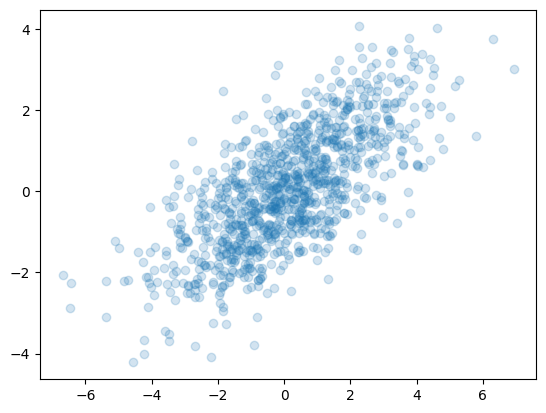

In [52]:
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.2)

In [8]:
import torch

mu = torch.tensor([0.0, 0.0])
cov = torch.tensor([[4.0, 2.0], [2.0, 2.0]])

# Create a generator with a fixed seed
generator = torch.Generator().manual_seed(42)

mvn = torch.distributions.MultivariateNormal(loc=mu, covariance_matrix=cov)
xs = mvn.sample((1000,))

In [9]:
xs.shape

torch.Size([1000, 2])